In [1]:
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

c:\Users\easyl\Documents\My_code\GitHub\RuReviews-sentiment\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0919 19:01:45.601000 17016 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


In [2]:
dataset = load_dataset("mteb/RuReviewsClassification")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2048
    })
})


In [3]:
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

negative    15000
neutral     15000
positive    15000
Name: count, dtype: int64


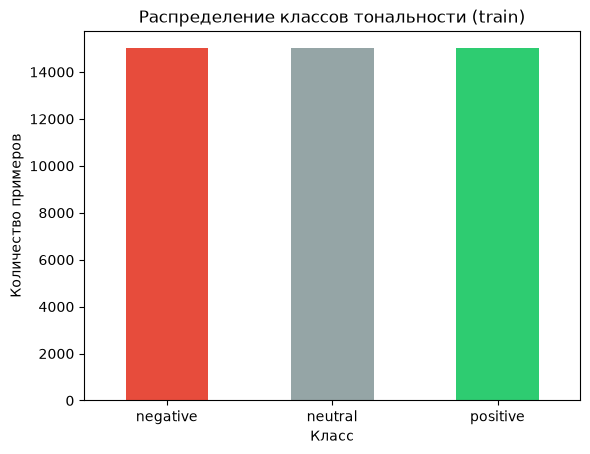

In [4]:
labels = dataset['train']['label']
counts = pd.Series(labels).value_counts().sort_index()
counts.index = counts.index.map(label_names)
print(counts)

counts.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Распределение классов тональности (train)')
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.xticks(rotation=0)
plt.show()

In [5]:
tokenizer_check = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')
lengths = [len(tokenizer_check.encode(text)) for text in dataset['train']['text'][:2000]]

print(f"Среднее: {np.mean(lengths):.1f}")
print(f"95-й перцентиль: {np.percentile(lengths, 95):.1f}")
print(f"Максимум: {np.max(lengths)}")

Среднее: 34.1
95-й перцентиль: 90.0
Максимум: 252


In [6]:
train_texts = dataset['train']['text']
train_labels = dataset['train']['label']
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train, train_labels)

baseline_preds = baseline_model.predict(X_test)
baseline_f1 = f1_score(test_labels, baseline_preds, average='macro')

print(f"Baseline F1 (macro): {baseline_f1:.4f}")
print(classification_report(test_labels, baseline_preds, target_names=['negative', 'neutral', 'positive']))

Baseline F1 (macro): 0.7353
              precision    recall  f1-score   support

    negative       0.72      0.70      0.71       682
     neutral       0.62      0.64      0.63       683
    positive       0.87      0.86      0.86       683

    accuracy                           0.73      2048
   macro avg       0.74      0.73      0.74      2048
weighted avg       0.74      0.73      0.74      2048



In [7]:
tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    'cointegrated/rubert-tiny2',
    num_labels=3
)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 36675.15it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the c

In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average='macro')
    accuracy = accuracy_score(labels, predictions)
    return {'f1': f1, 'accuracy': accuracy}

In [10]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_strategy='steps',
    logging_steps=100,
    seed=SEED,
)

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.587159,0.566241,0.751857,0.750867
2,0.546797,0.550919,0.760284,0.757933
3,0.496350,0.553916,0.762301,0.760333


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.85it/s]


TrainOutput(global_step=4221, training_loss=0.5601893436058639, metrics={'train_runtime': 67.9976, 'train_samples_per_second': 1985.365, 'train_steps_per_second': 62.076, 'total_flos': 248911937280000.0, 'train_loss': 0.5601893436058639, 'epoch': 3.0})

In [12]:
test_results = trainer.evaluate(eval_dataset=tokenized_dataset['test'])
print(test_results)

Training Loss,Validation Loss,Epoch,F1,Accuracy
0.496350,0.544915,3,0.763218,0.762207


{'eval_loss': 0.5449154376983643, 'eval_f1': 0.7632183486013965, 'eval_accuracy': 0.76220703125}


In [13]:
predictions_output = trainer.predict(tokenized_dataset['test'])
preds = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

print(classification_report(
    true_labels,
    preds,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))

              precision    recall  f1-score   support

    negative     0.7568    0.7302    0.7433       682
     neutral     0.6504    0.6837    0.6667       683
    positive     0.8869    0.8726    0.8797       683

    accuracy                         0.7622      2048
   macro avg     0.7647    0.7622    0.7632      2048
weighted avg     0.7647    0.7622    0.7632      2048

